## QRM millisecond acquisitions test

By sacrificing resolution, we can have one bin be a data point instead of 1 ns, and have a bin be whatever duration we need.

This is done by having acquiring for the resolution time, integrating over that acquisition, storing the result in a bin, and finally dividing that result by the acquisition time, so that the number in the bin is the average input value for its respective acquisition time.

There is a maximum of 131072 bins, and a maximum acquisition time for each bin of 16384 ns.

Attempting to read a signal from the lock-in amplifier.

Author: Kyle MacRobbie

### Setup

In [1]:
# Imports
import time
import json
import math
import matplotlib.pyplot as plt # type: ignore
import pyvisa # type: ignore
import numpy as np # type: ignore
import scipy # type: ignore
from numpy import random # type: ignore
from __future__ import annotations 
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument # type: ignore
from qblox_instruments import Cluster, ClusterType # type: ignore
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module # type: ignore

In [2]:
# Run to get cluster IP
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.9.2 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
# Connect to cluster
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'

# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]

cluster.led_brightness('medium')

# reset cluster and print cluster status
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, Flags: NONE, Slot flags: NONE


In [4]:
# Define which modules will be used
modules
qcm_module = modules[2]
qrm_module = modules[4]
rf_module = modules[6]

In [5]:
# Check QCM
print("\nQCM: {}\nQRM: {}\nRF: {}".format(qcm_module.is_qcm_type, qcm_module.is_qrm_type, qcm_module.is_rf_type))


QCM: True
QRM: False
RF: False


In [6]:
# Check QRM
print("\nQCM: {}\nQRM: {}\nRF: {}".format(qrm_module.is_qcm_type, qrm_module.is_qrm_type, qrm_module.is_rf_type))


QCM: False
QRM: True
RF: False


In [7]:
# Check QCM-RF
print("\nQCM: {}\nQRM: {}\nRF: {}".format(rf_module.is_qcm_type, rf_module.is_qrm_type, rf_module.is_rf_type))


QCM: True
QRM: False
RF: True


### End of setup

---
---

### Function to run the experiment for one iteration

In [9]:
def run_sequence(pulse_length, resolution):

	# Set the number of bins we will be using for this acquisition
	num_bins = round(pulse_length/resolution)
	print(f"# of bins: {num_bins}")

	# Set up the acquisition with the appropirate number of bins
	acquisitions = {
    	"acq": {"num_bins": num_bins, "index": 0},
	}

	# Set up out acquisition
	seq_in = f"""
		move 		0,R0			# Bin index
		move		{num_bins},R1   # Loop index

		wait_sync	4			# Sync with other sequencers if they're being used
		wait		150			# approximate time of flight
	loop:
		acquire		0,R0,{resolution}	# Acquire for one resolution period
		add			R0,1,R0				# Increment the bin index
		loop		R1,@loop			# Loop num_bins times

		stop
	"""

	sequence_in = {
		"waveforms": {},
		"weights": {},
		"acquisitions": acquisitions,
		"program": seq_in,
	}

	qrm_module.sequencer1.sequence(sequence_in) # Upload the sequence dictionary to the sequencer

	# Disconnect previous output connections outputs
	qrm_module.disconnect_outputs()
	qrm_module.disconnect_inputs()

	qrm_module.sequencer1.connect_acq_I("in0") # Acquire through first input

	qrm_module.scope_acq_sequencer_select(1) # Configure scope mode
	qrm_module.scope_acq_trigger_mode_path0("sequencer") # Set the scope acquisition to trigger off of the sequencer

	qrm_module.sequencer1.integration_length_acq(resolution) # integrate over the lengths of one acquisiton (resolution time)

	qrm_module.sequencer1.sync_en(True) # Enable sync with other sequencers if other sequencers are being used
	qrm_module.arm_sequencer(1) # Arm sequencer

	cluster.start_sequencer()	# Run the sequence

	qrm_module.get_acquisition_status(1) # Wait for the sequencer to stop with a timeout period of one minute.
	qrm_module.store_scope_acquisition(1, 'acq') # Move acquisition data from temporary memory to acquisition list.
	data = qrm_module.get_acquisitions(1) # Get acquisition list from instrument.
	
	# Print sequencer status
	print("QRM sequencer 1: " + str(qrm_module.get_sequencer_status(1)))

	return data

### Defining frequency, durations and looping through the pulse sequences

In [18]:
# Experiment variables
pulse_length_ = 5e6	# ns	# Length of the RF pulse (step 4)
resolution = 500 	# ns

readout_data = run_sequence(pulse_length_, resolution)	# Run the sequence

10000
QRM sequencer 1: Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_BINNING_DONE, Warning Flags: NONE, Error Flags: NONE, Log: []


### Plotting

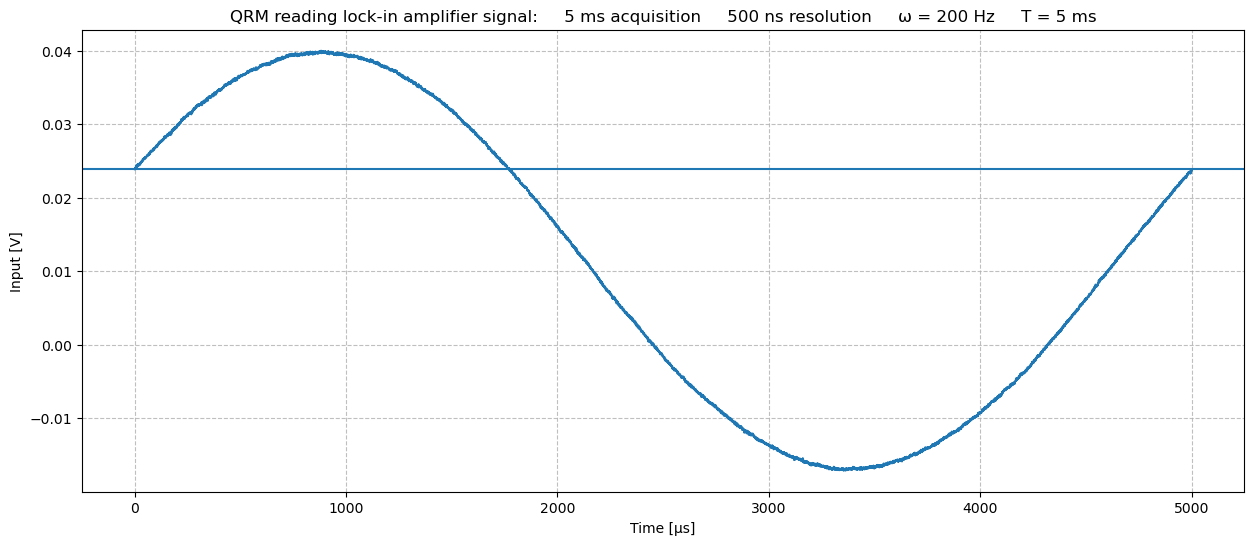

In [ ]:
# Extract the scope data for path 0
data = np.array(readout_data['acq']['acquisition']['bins']['integration']['path0'])
data = data/resolution # Divide by the resolution so that the value in the bin is the average value of its respective acquisition time
t = np.arange(resolution / 2, pulse_length_ + 0.1, resolution) # Make a list for the time for each bin

# Set up the figure
fig, ax = plt.subplots(1, 1, figsize = (15, 6))

t = t/1000 # Convert from ns to µs
ax.plot(t, data) # Plot data
ax.axhline(y = data[0]) # Make a line where the wave starts to ensure that it ends at the same value

# Setting titles
ax.set_ylabel("Input [V]")
ax.set_xlabel("Time [µs]")
ax.set_title(f"QRM reading lock-in amplifier signal:     {int(pulse_length_/1000000)} ms acquisition     {resolution} ns resolution     ω = 200 Hz     T = 5 ms")

ax.grid(ls = "--", alpha = 0.8) # Add a grid
plt.show()

### Stopping

In [24]:
cluster.stop_sequencer()

print("QRM sequencer 1: " + str(qrm_module.get_sequencer_status(1)))

cluster.reset()
print(cluster.get_system_status())

QRM sequencer 1: Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE
